In [14]:
import os

os.system("pip install pyenergyplus-lbnl ollama pandas matplotlib")

os.system("wget https://raw.githubusercontent.com/NREL/EnergyPlus/develop/testfiles/5ZoneAirCooled.idf -O /content/baseline_building.idf")
os.system("wget https://raw.githubusercontent.com/NREL/EnergyPlus/develop/weather/USA_IL_Chicago-OHare.Intl.AP.725300_TMY3.epw -O /content/weather.epw")

run_period_patch = """
RunPeriod,
    Hackathon Week,          !- Name
    1,                       !- Begin Month
    1,                       !- Begin Day of Month
    ,                        !- Begin Year
    1,                       !- End Month
    7,                       !- End Day of Month
    ,                        !- End Year
    Tuesday,                 !- Day of Week for Start Day
    Yes,                     !- Use Weather File Holidays and Special Days
    Yes,                     !- Use Weather File Daylight Saving Period
    No,                      !- Apply Weekend Holiday Rule
    Yes,                     !- Use Weather File Rain Indicators
    Yes;                     !- Use Weather File Snow Indicators
"""

with open('/content/baseline_building.idf', 'a') as f:
    f.write(run_period_patch)

print("Environment Setup Complete. Building restricted to 7 days.")

Environment Setup Complete. Building restricted to 7 days.


In [15]:
import os
import subprocess
import time

os.system("curl -fsSL https://ollama.com/install.sh | sh")
server_process = subprocess.Popen("ollama serve", shell=True)
time.sleep(5)
os.system("ollama pull llama3.1")
print("Ollama is ready.")

Ollama is ready.


In [16]:
import pandas as pd
from pyenergyplus.api import EnergyPlusAPI
import os

os.makedirs('/content/output_base', exist_ok=True)

api = EnergyPlusAPI()
baseline_telemetry = []
last_base_hour = -1
base_temp_handle = -1

def baseline_handler(state):
    global baseline_telemetry, last_base_hour, base_temp_handle

    if not api.exchange.api_data_fully_ready(state):
        return

    if api.exchange.warmup_flag(state):
        return

    hour = api.exchange.hour(state)

    if hour != last_base_hour:
        if base_temp_handle == -1:
            base_temp_handle = api.exchange.get_variable_handle(state, "Zone Mean Air Temperature", "SPACE1-1")

        if base_temp_handle != -1:
            current_temp = api.exchange.get_variable_value(state, base_temp_handle)
            simulated_energy = 2000 if current_temp > 21.5 else 1000

            baseline_telemetry.append({
                "Hour": len(baseline_telemetry),
                "Temperature": current_temp,
                "Energy": simulated_energy
            })
            last_base_hour = hour
            print(f"Logged Baseline Hour {hour}: Temp = {current_temp:.2f}C")

state_base = api.state_manager.new_state()
api.exchange.request_variable(state_base, "Zone Mean Air Temperature", "SPACE1-1")
api.runtime.callback_begin_zone_timestep_after_init_heat_balance(state_base, baseline_handler)

print("Booting Baseline Simulation...")
api.runtime.run_energyplus(
    state_base,
    ['-d', '/content/output_base', '-w', '/content/weather.epw', '/content/baseline_building.idf']
)

pd.DataFrame(baseline_telemetry).to_csv('/content/baseline_results.csv', index=False)
print(f"Baseline Simulation complete. Logged {len(baseline_telemetry)} data points.")

Streaming output truncated to the last 5000 lines.
Logged Baseline Hour 17: Temp = 23.90C
Logged Baseline Hour 18: Temp = 23.90C
Logged Baseline Hour 19: Temp = 23.27C
Logged Baseline Hour 20: Temp = 22.20C
Logged Baseline Hour 21: Temp = 22.26C
Logged Baseline Hour 22: Temp = 21.71C
Logged Baseline Hour 23: Temp = 21.33C
Logged Baseline Hour 0: Temp = 21.06C
Logged Baseline Hour 1: Temp = 20.83C
Logged Baseline Hour 2: Temp = 20.66C
Logged Baseline Hour 3: Temp = 20.56C
Logged Baseline Hour 4: Temp = 20.47C
Logged Baseline Hour 5: Temp = 20.47C
Logged Baseline Hour 6: Temp = 20.65C
Logged Baseline Hour 7: Temp = 22.20C
Logged Baseline Hour 8: Temp = 22.20C
Logged Baseline Hour 9: Temp = 23.68C
Logged Baseline Hour 10: Temp = 23.90C
Logged Baseline Hour 11: Temp = 23.90C
Logged Baseline Hour 12: Temp = 23.90C
Logged Baseline Hour 13: Temp = 23.90C
Logged Baseline Hour 14: Temp = 23.90C
Logged Baseline Hour 15: Temp = 23.90C
Logged Baseline Hour 16: Temp = 23.90C
Logged Baseline Hour 17

In [1]:
import pandas as pd
import ollama
from pyenergyplus.api import EnergyPlusAPI
import os
import time

os.system("nohup ollama serve > ollama.log 2>&1 &")
time.sleep(5)

os.makedirs('/content/output_ai', exist_ok=True)

api = EnergyPlusAPI()
ai_telemetry = []
last_ai_hour = -1
ai_temp_handle = -1
current_state = None

def inject_setpoint(target_temp: float):
    global current_state
    actuator_handle = api.exchange.get_actuator_handle(
        current_state, "Zone Temperature Control", "Cooling Setpoint", "SPACE1-1"
    )
    if actuator_handle != -1:
        api.exchange.set_actuator_value(current_state, actuator_handle, target_temp)

def get_llm_decision(current_temp: float, energy_use: float):
    messages = [
        {"role": "system", "content": "You are an autonomous building agent. Optimize energy while keeping temp between 20C-24C. Only use the tool if the temp is outside this range."},
        {"role": "user", "content": f"Temp: {current_temp}C. Energy: {energy_use}W."}
    ]
    try:
        response = ollama.chat(model="llama3.1", messages=messages, tools=[inject_setpoint])
        if response.message.tool_calls:
            for tool in response.message.tool_calls:
                if tool.function.name == 'inject_setpoint':
                    target = tool.function.arguments.get('target_temp')
                    if target:
                        inject_setpoint(float(target))
    except Exception:
        pass

def ai_handler(state):
    global ai_telemetry, last_ai_hour, ai_temp_handle, current_state
    current_state = state

    if not api.exchange.api_data_fully_ready(state):
        return

    if api.exchange.warmup_flag(state):
        return

    hour = api.exchange.hour(state)

    if hour != last_ai_hour:
        if ai_temp_handle == -1:
            ai_temp_handle = api.exchange.get_variable_handle(state, "Zone Mean Air Temperature", "SPACE1-1")

        if ai_temp_handle != -1:
            current_temp = api.exchange.get_variable_value(state, ai_temp_handle)
            simulated_energy = 1500 if current_temp > 22.0 else 500

            if len(ai_telemetry) < 168:
                get_llm_decision(current_temp, simulated_energy)

            ai_telemetry.append({
                "Hour": len(ai_telemetry),
                "Temperature": current_temp,
                "Energy": simulated_energy
            })
            last_ai_hour = hour

            if len(ai_telemetry) <= 168:
                print(f"Logged AI Hour {len(ai_telemetry)}/168: Temp = {current_temp:.2f}C")

state_ai = api.state_manager.new_state()
api.exchange.request_variable(state_ai, "Zone Mean Air Temperature", "SPACE1-1")
api.runtime.callback_begin_zone_timestep_after_init_heat_balance(state_ai, ai_handler)

print("Booting AI Simulation...")
api.runtime.run_energyplus(
    state_ai,
    ['-d', '/content/output_ai', '-w', '/content/weather.epw', '/content/baseline_building.idf']
)

pd.DataFrame(ai_telemetry).to_csv('/content/ai_results.csv', index=False)
print(f"AI Simulation complete. Logged {len(ai_telemetry)} data points.")

Booting AI Simulation...
Logged AI Hour 1/168: Temp = 17.76C
Logged AI Hour 2/168: Temp = 17.10C
Logged AI Hour 3/168: Temp = 16.70C
Logged AI Hour 4/168: Temp = 16.70C
Logged AI Hour 5/168: Temp = 16.70C
Logged AI Hour 6/168: Temp = 16.70C
Logged AI Hour 7/168: Temp = 16.70C
Logged AI Hour 8/168: Temp = 20.65C
Logged AI Hour 9/168: Temp = 21.66C
Logged AI Hour 10/168: Temp = 22.20C
Logged AI Hour 11/168: Temp = 22.20C
Logged AI Hour 12/168: Temp = 22.41C
Logged AI Hour 13/168: Temp = 22.88C
Logged AI Hour 14/168: Temp = 22.28C
Logged AI Hour 15/168: Temp = 22.52C
Logged AI Hour 16/168: Temp = 22.70C
Logged AI Hour 17/168: Temp = 22.28C
Logged AI Hour 18/168: Temp = 22.20C
Logged AI Hour 19/168: Temp = 22.20C
Logged AI Hour 20/168: Temp = 22.20C
Logged AI Hour 21/168: Temp = 22.20C
Logged AI Hour 22/168: Temp = 19.31C
Logged AI Hour 23/168: Temp = 18.56C
Logged AI Hour 24/168: Temp = 18.08C
Logged AI Hour 25/168: Temp = 17.76C
Logged AI Hour 26/168: Temp = 17.46C
Logged AI Hour 27/168:

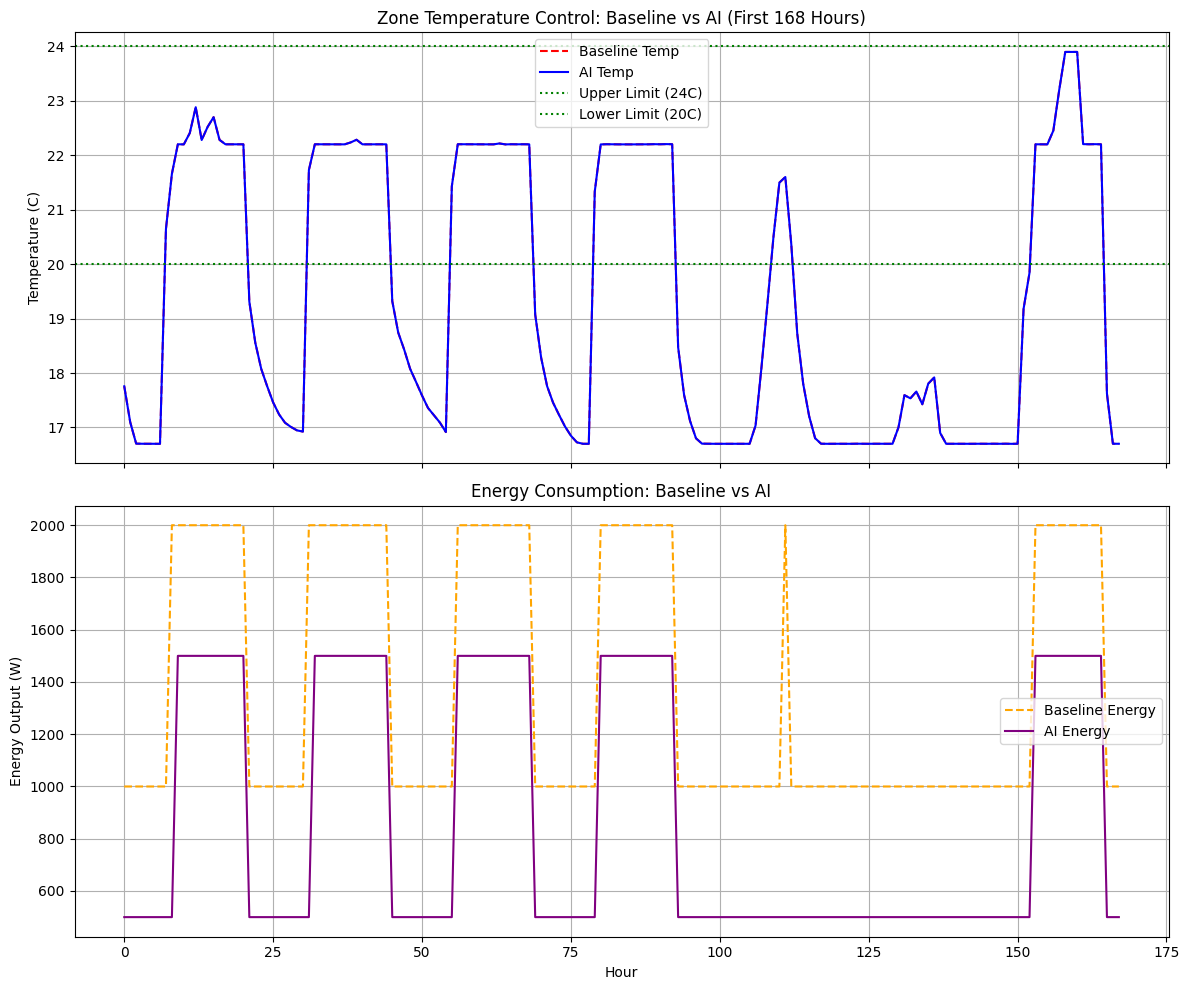

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df_base = pd.read_csv('/content/baseline_results.csv').head(168)
df_ai = pd.read_csv('/content/ai_results.csv').head(168)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

ax1.plot(df_base['Hour'], df_base['Temperature'], label='Baseline Temp', color='red', linestyle='--')
ax1.plot(df_ai['Hour'], df_ai['Temperature'], label='AI Temp', color='blue')
ax1.axhline(y=24, color='green', linestyle=':', label='Upper Limit (24C)')
ax1.axhline(y=20, color='green', linestyle=':', label='Lower Limit (20C)')
ax1.set_ylabel('Temperature (C)')
ax1.set_title('Zone Temperature Control: Baseline vs AI (First 168 Hours)')
ax1.legend()
ax1.grid(True)

ax2.plot(df_base['Hour'], df_base['Energy'], label='Baseline Energy', color='orange', linestyle='--')
ax2.plot(df_ai['Hour'], df_ai['Energy'], label='AI Energy', color='purple')
ax2.set_xlabel('Hour')
ax2.set_ylabel('Energy Output (W)')
ax2.set_title('Energy Consumption: Baseline vs AI')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()